# AAV2 Empty Capsid — Neutral pH: Significant Movements & Binding Event Matching

This notebook processes TandemMP/iSCAT particle-tracking data for AAV2 empty capsids at neutral pH.

## Pipeline overview

1. **Data loading** — load TandemMP `SaveFile` pickles for 21 neutral-pH runs
2. **Particle filtering** — apply mass/length/ghost criteria matching the paper notebooks (`filter_particles`, `min_mass=3000.0 kDa`)
3. **Movement detection** — extract frame-to-frame displacements exceeding a threshold (from `calc_mean_speed`); record the midpoint of each qualifying step
4. **Binding event matching** — match each significant movement back to a ratiometric binding event using a one-sided Gaussian likelihood scored on the binding anchor's localisation precision; anchor positions are updated sequentially to compensate for movement on the glass surface
5. **Series construction** — group matched pairs by binding anchor via `match_binding` to yield time-ordered `EventSeries`

## Motivation

The wider goal is to validate whether movement **midpoints alone** (as would be available from an independent detection source with no position history) are sufficient to recover the correct binding event assignment.  This notebook uses particle-tracking data — where the pipeline's own particle assignments are available for comparison — as the validation set.

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import os
import pathlib
import sys
from dataclasses import dataclass
from statistics import NormalDist as _NormalDist
from typing import List, Optional

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np

# ── TandemMP / project ────────────────────────────────────────────────────────
sys.path.insert(0, r'C:/Users/chem-bras5436/Documents/TandemMP_open_iscat')
sys.path.insert(0, r'C:/Users/chem-bras5436/Documents/TandemMP_open_iscat/alex_area')

from alex_area import utils
from tandemmp.io.save import SaveFile, PartData, RatiometricData

In [2]:
# ── Data location ─────────────────────────────────────────────────────────────
EMPTY_FOLDER = pathlib.Path(
    r'C:\Users\chem-bras5436\Documents\mp_diss_pathway_data\particle_tracking\aav_empty_full\empty'
)

# ── Acquisition ───────────────────────────────────────────────────────────────
FPS = 106.14 / 3   # neutral-pH frame rate (Hz); 106.14 Hz camera / 3 averaged frames
PX_SIZE = 72.6     # spatial calibration for particle positions (nm/pixel)

# ── Movement detection ────────────────────────────────────────────────────────
# Mirrors calc_mean_speed logic from paper notebooks
THRESHOLD = 1.5    # minimum frame-to-frame displacement (nm) to classify as significant
SKIP = 10          # frames to discard at the start of each trace (settling artefact)

# ── Particle filtering ────────────────────────────────────────────────────────
# Reproduces filter_particles(fps=neutral_fps, min_mass=3000.0 kDa) from paper
MIN_LENGTH         = 100     # minimum trace length (frames) after the buffer
FRAME_BUFFER       = 10      # frames excluded from the start when estimating initial mass
STARTING_MASS_LOW  = 3500.0  # lower bound on mean mass in first MIN_LENGTH frames (kDa)
STARTING_MASS_HIGH = 4000.0  # upper bound on mean mass in first MIN_LENGTH frames (kDa)
MASS_BUFFER        = 500.0   # tolerance above STARTING_MASS_HIGH for lifetime max mass (kDa)
MIN_MASS           = 3000.0  # absolute minimum mass at any frame (kDa)

# ── Matching ──────────────────────────────────────────────────────────────────
# mass_to_sigma (tandemmp/utils/conversions.py) uses 84.4 nm/px internally —
# distinct from PX_SIZE (72.6 nm/px) used for particle positions.  Multiply
# mass_to_sigma output by _SIGMA_NM_SCALE to convert pixels → nm.
_SIGMA_NM_SCALE = 84.4

## 1. Data Discovery

In [3]:
# Select AAV2 empty neutral-pH TandemMP SaveFiles.
# Exclusion rules:
#   .mp suffix   — raw iSCAT movies, not processed SaveFiles
#   'pH'         — pH-titration series (separate experiment)
#   'APTES'      — APTES-functionalised surface runs (different condition)
neutral_fps = [
    EMPTY_FOLDER / file
    for file in sorted(os.listdir(EMPTY_FOLDER))
    if (
        not file.endswith('.mp')
        and 'aav2_empty' in file
        and 'tandemmp' in file
        and 'pH' not in file
        and 'APTES' not in file
    )
]

print(f'Found {len(neutral_fps)} AAV2 empty neutral files:')
for fp in neutral_fps:
    print(f'  {fp.name}')

Found 21 AAV2 empty neutral files:
  003_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  004_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  005_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  006_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  007_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  008_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  010_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  011_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  012_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  013_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  016_20260217_aav2_empty_50x_tandemmp_navg5_2026-02-19
  017_20260217_aav2_empty_50x_tandemmp_navg5_2026-02-19
  018_20260217_aav2_empty_50x_tandemmp_navg5_2026-02-19
  019_20260217_aav2_empty_50x_tandemmp_navg5_2026-02-19
  020_20260217_aav2_empty_50x_tandemmp_navg5_2026-02-19
  021_20260217_aav2_empty_50x_tandemmp_navg5_2026-02-19
  022_20260217_aav2_empty_50x_tandemmp_navg5_2026-02-19
  023_2026021

## 2. Data Structures

In [4]:
@dataclass
class SignificantMovement:
    """A single frame-to-frame displacement that exceeds THRESHOLD.

    All positions are in nm.  `particle_id` is the TandemMP particle ID of the
    source particle, carried through so that aggregated file-level lists retain
    per-particle provenance for downstream validation.  `midpoint_x_nm` /
    `midpoint_y_nm` are the primary spatial queries used in binding-event
    matching — they are the only position available when movements originate
    from an external detection source.
    """
    particle_id:     int
    frame_index:     int
    x_start_nm:      float
    y_start_nm:      float
    x_end_nm:        float
    y_end_nm:        float
    displacement_nm: float
    midpoint_x_nm:   float
    midpoint_y_nm:   float


@dataclass
class ParticleREvents:
    """Ratiometric events assigned by the TandemMP pipeline to a single particle.

    Each list element corresponds to one ratiometric event.  `masses` holds a
    numpy array of per-frame mass estimates for that event (not a scalar).
    `classifications` and `decisions` may be None for events whose pipeline
    decision was 'failed' or 'ignore'.
    """
    frames:          List[int]
    masses:          List[np.ndarray]
    contrasts:       List[float]
    x_pos:           List[float]
    y_pos:           List[float]
    dx:              List[float]
    dy:              List[float]
    classifications: List[Optional[str]]
    decisions:       List[Optional[str]]
    errors:          List[float]
    snrs:            List[float]
    direct_overlap:  List[bool]


@dataclass
class ParticleResult:
    """All processed data for a single filtered particle."""
    particle_id:           int
    r_events:              ParticleREvents
    significant_movements: List[SignificantMovement]


@dataclass
class FileResult:
    """All processed data for a single TandemMP SaveFile.

    `all_r_events` is the complete, unfiltered RatiometricData for the file.
    It is retained at file scope so that binding-event matching can query
    across all events, not just those assigned to the particle being processed.
    """
    filepath:         pathlib.Path
    particle_results: List[ParticleResult]
    all_r_events:     RatiometricData

## 3. Processing Pipeline

In [5]:
def passes_filter(part: PartData) -> bool:
    """Return True if this particle passes the neutral AAV2 empty selection criteria.

    Reproduces filter_particles(fps=neutral_fps, min_mass=3000.0 kDa) from the
    paper notebooks.  Ghost particles are excluded unconditionally.
    """
    if part.is_ghost:
        return False
    if len(part.masses) <= MIN_LENGTH + FRAME_BUFFER:
        return False

    window = slice(FRAME_BUFFER, MIN_LENGTH + FRAME_BUFFER)
    mean_initial_mass = np.mean(part.masses[window])

    in_mass_window   = STARTING_MASS_LOW < mean_initial_mass < STARTING_MASS_HIGH
    below_mass_ceil  = np.max(part.masses[FRAME_BUFFER:]) < STARTING_MASS_HIGH + MASS_BUFFER
    above_mass_floor = np.min(part.masses[FRAME_BUFFER:]) > MIN_MASS

    return in_mass_window and below_mass_ceil and above_mass_floor


def get_significant_movements(part: PartData, particle_id: int) -> List[SignificantMovement]:
    """Extract frame-to-frame displacements exceeding THRESHOLD nm.

    Reproduces the movement selection in calc_mean_speed from the paper
    notebooks.  The first SKIP frames are dropped to avoid settling artefacts.
    Returns one SignificantMovement per qualifying step, sorted by frame_index.
    `particle_id` is embedded in each movement for downstream provenance tracking.

    `frame_index` stores the **global movie frame** via `part.frames[SKIP + j]`.
    After `PartData.__post_init__` runs `make_continuous`, `part.frames` is a
    dense array of global frame numbers starting at the particle's first
    fixed-background event — not a local particle-age index.  Global frames are
    required so that `time_between = frame_index - binding_frame` is physically
    meaningful in the matching step.
    """
    x_nm = np.array(part.x_pos[SKIP:]) * PX_SIZE
    y_nm = np.array(part.y_pos[SKIP:]) * PX_SIZE

    displacements = np.hypot(np.diff(x_nm), np.diff(y_nm))
    sig_indices   = np.where(displacements > THRESHOLD)[0]

    return [
        SignificantMovement(
            particle_id=particle_id,
            frame_index=int(part.frames[SKIP + j]),  # global movie frame, not local index
            x_start_nm=float(x_nm[j]),
            y_start_nm=float(y_nm[j]),
            x_end_nm=float(x_nm[j + 1]),
            y_end_nm=float(y_nm[j + 1]),
            displacement_nm=float(displacements[j]),
            midpoint_x_nm=float((x_nm[j] + x_nm[j + 1]) / 2.0),
            midpoint_y_nm=float((y_nm[j] + y_nm[j + 1]) / 2.0),
        )
        for j in sig_indices
    ]

In [6]:
# Process each SaveFile independently — data from different files is NEVER
# aggregated, because ratiometric event indices are file-local.
all_file_results: dict[str, FileResult] = {}

for fp in neutral_fps:
    print(f'\nProcessing: {fp.name}')
    save: SaveFile = utils.load_from_pickle(fp)

    r_events = save.r_events
    # r_events.particle[k] is the particle ID (int) or None per event.
    # Set during the pipeline's decision-enactment phase; may be None for
    # failed/ignored actions.  Stored as a list for fast index lookup.
    r_events_by_particle = list(r_events.particle)

    particle_results: List[ParticleResult] = []

    for part in save.particles:
        if not passes_filter(part):
            continue

        pid = part.particle
        # Collect the subset of file-level r_events the pipeline assigned to
        # this particle.  Stored in ParticleResult for reference; the matching
        # step uses all_r_events (the complete file-level set) instead.
        event_indices = [k for k, p in enumerate(r_events_by_particle) if p == pid]

        part_r_events = ParticleREvents(
            frames=          [r_events.frames[k]          for k in event_indices],
            masses=          [r_events.masses[k]          for k in event_indices],
            contrasts=       [r_events.contrasts[k]       for k in event_indices],
            x_pos=           [r_events.x_pos[k]           for k in event_indices],
            y_pos=           [r_events.y_pos[k]           for k in event_indices],
            dx=              [r_events.dx[k]              for k in event_indices],
            dy=              [r_events.dy[k]              for k in event_indices],
            classifications= [r_events.classifications[k] for k in event_indices],
            decisions=       [r_events.decisions[k]       for k in event_indices],
            errors=          [r_events.errors[k]          for k in event_indices],
            snrs=            [r_events.snrs[k]            for k in event_indices],
            direct_overlap=  [r_events.direct_overlap[k]  for k in event_indices],
        )

        particle_results.append(
            ParticleResult(
                particle_id=pid,
                r_events=part_r_events,
                significant_movements=get_significant_movements(part, pid),
            )
        )

    all_file_results[fp.name] = FileResult(
        filepath=fp,
        particle_results=particle_results,
        all_r_events=r_events,  # full file-level event set — retained for global matching
    )

    n_sig = sum(len(pr.significant_movements) for pr in particle_results)
    print(f'  {len(particle_results)} filtered particles, {n_sig} total significant movements')


Processing: 003_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  33 filtered particles, 4221 total significant movements

Processing: 004_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  69 filtered particles, 4589 total significant movements

Processing: 005_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  59 filtered particles, 5309 total significant movements

Processing: 006_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  57 filtered particles, 4219 total significant movements

Processing: 007_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  60 filtered particles, 4235 total significant movements

Processing: 008_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  50 filtered particles, 5865 total significant movements

Processing: 010_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  46 filtered particles, 4036 total significant movements

Processing: 011_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
  61 filtered particles, 5105 total significant movements


## 4. Exploratory Analysis

In [7]:
# Per-file summary: filtered particle count and total significant movements.
print(f"{'File':<60} {'Particles':>9} {'Sig. Movs':>10}")
print('-' * 82)
for fname, fdata in all_file_results.items():
    n_parts = len(fdata.particle_results)
    n_sig   = sum(len(pr.significant_movements) for pr in fdata.particle_results)
    print(f'{fname:<60} {n_parts:>9} {n_sig:>10}')

File                                                         Particles  Sig. Movs
----------------------------------------------------------------------------------
003_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27               33       4221
004_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27               69       4589
005_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27               59       5309
006_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27               57       4219
007_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27               60       4235
008_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27               50       5865
010_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27               46       4036
011_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27               61       5105
012_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27               66       7922
013_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27               52       4391
016_20260217_aa

In [8]:
# Spot-check: inspect the first filtered particle from the first file.
# Verify that r_events.masses are arrays (not scalars) and that significant
# movements are correctly ordered by frame index with midpoints in nm.
first_fname    = list(all_file_results.keys())[0]
first_file     = all_file_results[first_fname]
first_particle = first_file.particle_results[1]

print(f'File: {first_fname}')
print(f'Particle ID: {first_particle.particle_id}')

re = first_particle.r_events
print(f'\nPipeline-assigned ratiometric events ({len(re.frames)}):')
print('  frames:         ', re.frames[:5])
print('  classifications:', re.classifications[:5])
print('  decisions:      ', re.decisions[:5])
print('  mass:           ', [np.round(np.mean(re.masses), 2)] if re.masses else 'none')

movs = first_particle.significant_movements
print(f'\nSignificant movements ({len(movs)} total, first 5):')
for m in movs[:5]:
    print(f'  frame {m.frame_index:>5}: ({m.x_start_nm:.2f}, {m.y_start_nm:.2f}) -> '
          f'({m.x_end_nm:.2f}, {m.y_end_nm:.2f})  '
          f'disp={m.displacement_nm:.2f} nm  '
          f'mid=({m.midpoint_x_nm:.2f}, {m.midpoint_y_nm:.2f})')

File: 003_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
Particle ID: 133

Pipeline-assigned ratiometric events (1):
  frames:          [33]
  classifications: ['Binding']
  decisions:       ['create_new']
  mass:            [3485.77]

Significant movements (86 total, first 5):
  frame    43: (4779.12, 5721.20) -> (4776.72, 5714.29)  disp=7.32 nm  mid=(4777.92, 5717.74)
  frame    49: (4776.75, 5716.16) -> (4778.93, 5720.57)  disp=4.91 nm  mid=(4777.84, 5718.37)
  frame    50: (4778.93, 5720.57) -> (4781.11, 5725.71)  disp=5.58 nm  mid=(4780.02, 5723.14)
  frame    55: (4780.20, 5724.79) -> (4779.43, 5722.72)  disp=2.21 nm  mid=(4779.81, 5723.75)
  frame    58: (4779.28, 5720.53) -> (4780.11, 5724.15)  disp=3.72 nm  mid=(4779.70, 5722.34)


In [9]:
# Distribution of significant-movement counts per particle.
# The 99.9th percentile informs the max_pairs ceiling in the matching step.
movement_counts = [
    len(pr.significant_movements)
    for fdata in all_file_results.values()
    for pr in fdata.particle_results
]
print('Significant movements per particle — percentiles [0, 25, 50, 75, 99.9]:')
np.percentile(movement_counts, [0, 25, 50, 75, 99.9])

Significant movements per particle — percentiles [0, 25, 50, 75, 99.9]:


array([  0.  ,  27.  ,  60.  , 121.  , 855.34])

## 5. Movement-to-Binding Matching

Each significant movement is matched back to the most likely ratiometric binding event using a one-sided Gaussian likelihood scored on the anchor's localisation precision (`mass_to_sigma`).  Matching is **global** — performed against all negative-contrast events in the file, not just those pipeline-assigned to the current particle — so that the recovered anchor IDs can be compared against the pipeline's own assignments as a validation step.

In [10]:
# FakeEvent / Pair  — lightweight event containers compatible with match_binding
# mass_to_sigma     — localisation precision in pixels at 84.4 nm/px; used to
#                     derive the Gaussian likelihood width for each binding anchor
# match_binding     — groups List[Pair] by binding event identity into EventSeries
from tandemmp.simple_analysis import FakeEvent, Pair
from tandemmp.utils.conversions import mass_to_sigma
from pairmatching_kinetics.kinetic_functions import match_binding, EventSeries

In [11]:
# Classification labels accepted as binding anchors.  Positive-contrast events
# are excluded by the c >= 0 check below; this filter removes purely spurious
# or irrelevant classification types.
ALLOWED_CLASSIFICATIONS = ('Association', 'Binding', 'Dissociation', None, 'Unbinding')


def match_file_movements(
    file_result: FileResult,
    sigma_multiplier: float = 5.0,
    max_pairs: int = 1000,
    analyse_distance: float = 300.0,  # nm; coarse spatial pre-filter
    minimum_likelihood: float = 0.01, # min NormalDist(sigma_binding).pdf(distance) to accept
) -> List[Pair]:
    """Match all significant movements in a file against all ratiometric binding events.

    Rather than matching per-particle, all movements from all particles are
    aggregated into a single time-sorted list and matched in one pass against
    binding anchors built from the complete file-level RatiometricData.  This
    ensures that anchor position updates from earlier movements (within any
    particle) are visible when scoring later movements — the intended behaviour
    of the sequential anchor update.

    Cross-particle anchor contamination is not a realistic risk: the 300 nm
    spatial gate is a ~10x margin against the typical ~3-4 μm inter-particle
    spacing, so each anchor is effectively driven only by movements from the
    particle it is spatially co-located with.

    ## ID scheme
    Both binding anchors and movements encode the particle tracking ID so that
    recovered EventSeries can be validated by visual inspection:
      anchor  id: "P{pipeline_particle} (anchor, {cls})"
      movement id: "P{source_particle_id} (mov)"
    A correct recovery shows the same particle ID in the anchor and all
    movements of a series.  `P{pipeline_particle}` may be PNone for ratiometric
    events that the pipeline left unassigned.

    ## Scoring
    score = NormalDist(mu=0, sigma=mass_to_sigma(m) * _SIGMA_NM_SCALE
                       * sigma_multiplier).pdf(distance_to_midpoint)
    Only the binding anchor's localisation-precision sigma enters; movements
    are treated as point observations.

    ## Sequential anchor update
    After each successful match, b_x[i] and b_y[i] advance to the matched
    midpoint so that subsequent movements score against the particle's most
    recently observed position rather than the stale binding-detection position.
    The FakeEvent objects are NOT mutated — Pair.binding.x/y always holds the
    original detection position.
    """
    all_r_events = file_result.all_r_events

    # Aggregate all movements across particles and sort by frame_index.
    # particle_id is embedded in each SignificantMovement for provenance.
    all_movements = sorted(
        (mov for pr in file_result.particle_results for mov in pr.significant_movements),
        key=lambda m: m.frame_index,
    )
    if not all_movements:
        return []

    # ── Build binding anchors from all file-level ratiometric events ──────────
    # Anchor id encodes the pipeline-assigned particle ID so that validation
    # can compare it against the source particle IDs of matched movements.
    binding_events: List[FakeEvent] = []
    for k in range(len(all_r_events.frames)):
        if all_r_events.classifications[k] not in ALLOWED_CLASSIFICATIONS:
            continue
        c = float(np.mean(all_r_events.contrasts[k]))
        if c >= 0:
            continue  # positive contrast → particle departing; not a binding anchor
        m   = float(np.mean(all_r_events.masses[k]))
        x   = float(np.mean(all_r_events.x_pos[k])) * PX_SIZE
        y   = float(np.mean(all_r_events.y_pos[k])) * PX_SIZE
        cls = all_r_events.classifications[k]
        pid = all_r_events.particle[k]
        binding_events.append(
            FakeEvent(c=c, m=m, x=x, y=y, i=all_r_events.frames[k],
                      id=f"P{pid} (anchor, {cls})")
        )

    if not binding_events:
        return []

    # ── Mutable working arrays — built once per file, shared across all movements ──
    # b_x / b_y advance after each match; FakeEvent objects remain unchanged.
    b_x     = np.array([e.x for e in binding_events], dtype=float)
    b_y     = np.array([e.y for e in binding_events], dtype=float)
    b_i     = np.array([e.i for e in binding_events])
    b_sigma = np.array([
        mass_to_sigma(e.m) * _SIGMA_NM_SCALE * sigma_multiplier
        for e in binding_events
    ])
    pairs_left = np.full(len(binding_events), max_pairs)
    pairs: List[Pair] = []

    # ── Single pass over all time-sorted movements ────────────────────────────
    # Because all_movements is time-sorted, each anchor update is immediately
    # visible to all later movements, regardless of which particle they come from.
    for mov in all_movements:
        x_q = mov.midpoint_x_nm
        y_q = mov.midpoint_y_nm

        spatial_dist = np.hypot(b_x - x_q, b_y - y_q)
        time_between = mov.frame_index - b_i
        suitable     = (spatial_dist < analyse_distance) & (time_between > 0)

        if not suitable.any():
            continue

        likelihoods = np.array([
            _NormalDist(0, sig).pdf(dist)
            for dist, sig in zip(spatial_dist[suitable], b_sigma[suitable])
        ])

        over_minimum = likelihoods > minimum_likelihood
        if not over_minimum.any():
            continue

        best       = int(np.argmax(likelihoods[over_minimum]))
        global_idx = int(np.where(suitable)[0][over_minimum][best])
        anchor     = binding_events[global_idx]

        if pairs_left[global_idx] > 0:
            fake_mov = FakeEvent(
                c=np.nan, m=np.nan, x=x_q, y=y_q,
                i=mov.frame_index, id=f"P{mov.particle_id} (mov)",
            )
            pairs.append(Pair(
                binding=anchor,
                unbinding=fake_mov,
                time=float(time_between[global_idx]),
                distance=float(spatial_dist[global_idx]),
                overlap=float(likelihoods[over_minimum][best]),
                order=int(max_pairs - pairs_left[global_idx]),
            ))
            pairs_left[global_idx] -= 1

            # Advance this anchor's tracked position to the matched midpoint.
            # Subsequent movements score against the current particle position
            # rather than the stale binding-detection position.
            b_x[global_idx] = x_q
            b_y[global_idx] = y_q

    return pairs

In [12]:
# sig = mass_to_sigma(6000) * _SIGMA_NM_SCALE * 5.0
# _NormalDist(0, sig).pdf(25)

In [13]:
# Run the full matching pipeline across all files.
#
# For each file: aggregate all movements from all particles into a single
# time-sorted list, match against all file-level binding anchors in one pass,
# then group the resulting pairs by binding anchor identity into EventSeries.
#
# Output structure: all_event_series[filename] -> List[EventSeries]
# Each EventSeries contains one binding anchor and all movements matched to it,
# sorted by frame index.  The anchor and movement ids encode particle IDs for
# validation (see cell below).
all_event_series: dict[str, List[EventSeries]] = {}

for fname, file_result in all_file_results.items():
    pairs       = match_file_movements(file_result)
    series_list = match_binding(pairs) if pairs else []
    all_event_series[fname] = series_list

    n_parts = len(file_result.particle_results)
    print(f'{fname}: {len(series_list)} series from {n_parts} particles')

Matching pairs by binding event: 100%|██████████| 3606/3606 [00:00<00:00, 150198.22it/s]


003_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27: 32 series from 33 particles


Matching pairs by binding event: 100%|██████████| 4093/4093 [00:00<00:00, 86605.05it/s]


004_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27: 69 series from 69 particles


Matching pairs by binding event: 100%|██████████| 4719/4719 [00:00<00:00, 108398.53it/s]


...

024_20260217_aav2_empty_50x_tandemmp_navg5_2026-02-20: 30 series from 29 particles


Matching pairs by binding event: 100%|██████████| 3849/3849 [00:00<00:00, 98696.44it/s]

025_20260217_aav2_empty_50x_tandemmp_navg5_2026-02-19: 45 series from 45 particles



Matching pairs by binding event: 100%|██████████| 3124/3124 [00:00<00:00, 121445.57it/s]

026_20260217_aav2_empty_50x_tandemmp_navg5_2026-02-20: 37 series from 39 particles


## 6. Results & Validation

In [19]:
# Validation: inspect recovered EventSeries and quantify how often the
# globally-matched binding anchor recovers the correct per-particle assignment.
#
# ID scheme (set in match_file_movements):
#   anchor  id: "P{pipeline_particle} (anchor, {cls})"  — pipeline-assigned particle
#   movement id: "P{source_particle}  (mov)"            — particle the movement came from
#
# A correct recovery: anchor particle ID == source particle ID for all movements.
# Mismatches flag either a wrong anchor match or an unassigned pipeline event.

def _pid_from_id(id_str: str) -> str:
    """Extract 'P{N}' particle tag from a FakeEvent id string."""
    return id_str.split()[0]  # e.g. "P132 (anchor, Binding)" -> "P132"


# ── Detailed view of a sample file ───────────────────────────────────────────
first_fname   = '007_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27'
series_list   = all_event_series[first_fname]

print(f'File: {first_fname}')
print(f'{len(series_list)} EventSeries total\n')

for s_idx, series in enumerate(series_list):
    events     = series.events
    anchor_ev  = next(ev for ev in events if not np.isnan(ev.c))
    mov_events = [ev for ev in events if np.isnan(ev.c)]
    anchor_pid = _pid_from_id(anchor_ev.id)
    match_ok   = all(_pid_from_id(ev.id) == anchor_pid for ev in mov_events)

    if not match_ok:
        print(f'Series {s_idx:>3}  {"[OK]" if match_ok else "[MISMATCH]":10}  '
            f'{len(mov_events)} movements')
        print(f'  anchor  : frame={anchor_ev.i:>5}  m={anchor_ev.m:>7.0f} kDa  '
            f'pos=({anchor_ev.x:>8.1f}, {anchor_ev.y:>8.1f}) nm  id={anchor_ev.id}')
        for ev in mov_events:
            print(f'  movement: frame={ev.i:>5}  '
                f'pos=({ev.x:>8.1f}, {ev.y:>8.1f}) nm  id={ev.id}')
        # if len(mov_events) > 5:
        #     print(f'  ... ({len(mov_events) - 5} more movements)')
        print()

# ── Quantitative validation across all files ─────────────────────────────────
print('─' * 70)
print(f'{"File":<52} {"Series":>6} {"Correct":>8} {"Mixed":>6} {"Wrong":>6}')
print('─' * 70)

total_series = total_correct = total_mixed = total_wrong = 0

for fname, series_list in all_event_series.items():
    n_series = n_correct = n_mixed = n_wrong = 0

    for series in series_list:
        anchor_ev  = next((ev for ev in series.events if not np.isnan(ev.c)), None)
        mov_events = [ev for ev in series.events if np.isnan(ev.c)]
        if anchor_ev is None or not mov_events:
            continue

        anchor_pid  = _pid_from_id(anchor_ev.id)
        source_pids = {_pid_from_id(ev.id) for ev in mov_events}
        n_series += 1

        if source_pids == {anchor_pid}:
            n_correct += 1
        elif len(source_pids) > 1:
            n_mixed += 1
        else:
            n_wrong += 1

    total_series  += n_series
    total_correct += n_correct
    total_mixed   += n_mixed
    total_wrong   += n_wrong

    pct = 100 * n_correct / n_series if n_series else 0
    print(f'{fname:<52} {n_series:>6} {n_correct:>7} ({pct:>4.1f}%) '
          f'{n_mixed:>5}  {n_wrong:>5}')

print('─' * 70)
overall_pct = 100 * total_correct / total_series if total_series else 0
print(f'{"TOTAL":<52} {total_series:>6} {total_correct:>7} ({overall_pct:>4.1f}%) '
      f'{total_mixed:>5}  {total_wrong:>5}')
print()
print('Correct  — all movements match the anchor\'s pipeline-assigned particle')
print('Mixed    — movements from more than one particle matched to same anchor')
print('Wrong    — all movements from a different particle than the anchor')

File: 007_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27
53 EventSeries total

Series   8  [MISMATCH]  274 movements
  anchor  : frame=  258  m=   2221 kDa  pos=(  2769.4,   9074.2) nm  id=PNone (anchor, Binding)
  movement: frame=  266  pos=(  2784.9,   9084.5) nm  id=P27 (mov)
  movement: frame=  267  pos=(  2784.1,   9083.9) nm  id=P27 (mov)
  movement: frame=  268  pos=(  2785.8,   9085.0) nm  id=P27 (mov)
  movement: frame=  270  pos=(  2784.3,   9086.5) nm  id=P27 (mov)
  movement: frame=  271  pos=(  2780.3,   9087.0) nm  id=P27 (mov)
  movement: frame=  272  pos=(  2781.8,   9086.6) nm  id=P27 (mov)
  movement: frame=  273  pos=(  2786.0,   9086.1) nm  id=P27 (mov)
  movement: frame=  275  pos=(  2787.1,   9086.4) nm  id=P27 (mov)
  movement: frame=  301  pos=(  2787.0,   9086.9) nm  id=P27 (mov)
  movement: frame=  302  pos=(  2787.3,   9087.8) nm  id=P27 (mov)
  movement: frame=  308  pos=(  2787.0,   9087.7) nm  id=P27 (mov)
  movement: frame=  310  pos=(  2787.0,   9088.

In [47]:
r_evs = all_file_results['007_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27'].all_r_events
match_indices = [i for i, pid in enumerate(r_evs.particle) if pid == 27]

print(match_indices)
print(np.mean(r_evs.x_pos[match_indices[0]]) * PX_SIZE)
print(np.mean(r_evs.y_pos[match_indices[0]]) * PX_SIZE)
print(r_evs.frames[match_indices[0]])

[39]
2764.5464138834545
9086.34625008444
256


[72]
5737.8451228062195
-655.3323418006833
497


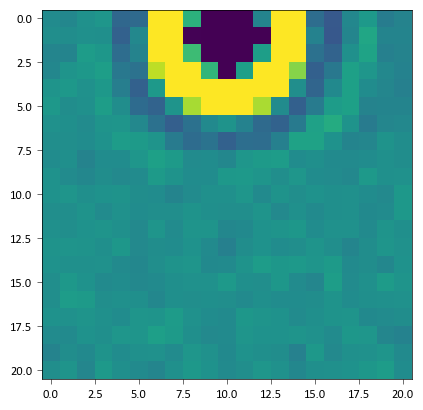

In [58]:
r_evs = all_file_results['007_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27'].all_r_events
match_indices = [i for i, pid in enumerate(r_evs.particle) if pid == 43]

print(match_indices)
print(np.mean(r_evs.x_pos[match_indices[0]]) * PX_SIZE)
print(np.mean(r_evs.y_pos[match_indices[0]]) * PX_SIZE)
print(r_evs.frames[match_indices[0]])

import matplotlib.pyplot as plt
plt.imshow(r_evs.images[match_indices[0]], vmin=-0.01, vmax=0.01)

In [46]:
r_evs = all_file_results['007_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27'].all_r_events
match_indices = [i for i, pid in enumerate(r_evs.particle) if pid == 42]

print(match_indices)
print(np.mean(r_evs.x_pos[match_indices[0]]) * PX_SIZE)
print(np.mean(r_evs.y_pos[match_indices[0]]) * PX_SIZE)
print(r_evs.frames[match_indices[0]])

[71, 119, 207]
5796.25867556985
-520.4384715889921
495


## 7. Movement Recovery Rate

For each particle, compare the number of significant movements detected in the tracking data against the number recovered by the matching pipeline (i.e. movements that ended up in an `EventSeries`).  A movement is "recovered" if the matching step found a binding anchor with sufficient likelihood; unrecovered movements either had no anchor within the spatial/temporal window or fell below `minimum_likelihood`.

In [ ]:
# Build per-file recovered-movement counts keyed by particle tag ("P{pid}").
# Each movement in all_event_series is counted once — the matching loop in
# match_file_movements produces at most one Pair per movement.
recovered_by_file: dict[str, dict[str, int]] = {}

for fname, series_list in all_event_series.items():
    counts: dict[str, int] = {}
    for series in series_list:
        for ev in series.events:
            if np.isnan(ev.c):  # movement events have c=nan; anchors have negative float
                tag = _pid_from_id(ev.id)
                counts[tag] = counts.get(tag, 0) + 1
    recovered_by_file[fname] = counts

# ── Per-file summary ──────────────────────────────────────────────────────────
print(f"{'File':<52} {'Total movs':>11} {'Recovered':>10} {'Recall':>7}")
print('─' * 84)

grand_total = grand_recovered = 0

for fname, file_result in all_file_results.items():
    recovered_map  = recovered_by_file.get(fname, {})
    file_total     = sum(len(pr.significant_movements) for pr in file_result.particle_results)
    file_recovered = sum(
        recovered_map.get(f"P{pr.particle_id}", 0)
        for pr in file_result.particle_results
    )
    grand_total     += file_total
    grand_recovered += file_recovered
    recall = 100 * file_recovered / file_total if file_total else 0
    print(f'{fname:<52} {file_total:>11,} {file_recovered:>10,}  {recall:>5.1f}%')

print('─' * 84)
overall_recall = 100 * grand_recovered / grand_total if grand_total else 0
print(f'{"TOTAL":<52} {grand_total:>11,} {grand_recovered:>10,}  {overall_recall:>5.1f}%')

# ── Per-particle breakdown for the first file ─────────────────────────────────
sample_fname = list(all_file_results.keys())[0]
sample_file  = all_file_results[sample_fname]
sample_rec   = recovered_by_file.get(sample_fname, {})

print(f'\nPer-particle breakdown — {sample_fname}:')
print(f"{'Particle':>10} {'Total movs':>11} {'Recovered':>10} {'Recall':>7}")
print('─' * 45)
for pr in sample_file.particle_results:
    tag    = f"P{pr.particle_id}"
    total  = len(pr.significant_movements)
    rec    = sample_rec.get(tag, 0)
    recall = 100 * rec / total if total else 0
    print(f'{tag:>10} {total:>11,} {rec:>10,}  {recall:>5.1f}%')

File                                                  Total movs  Recovered  Recall
────────────────────────────────────────────────────────────────────────────────────
003_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27       4,221      3,606   85.4%
004_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27       4,589      4,093   89.2%
005_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27       5,309      4,719   88.9%
006_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27       4,219      3,468   82.2%
007_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27       4,235      3,433   81.1%
008_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27       5,865      5,548   94.6%
010_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27       4,036      3,915   97.0%
011_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27       5,105      3,823   74.9%
012_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27       7,922      7,096   89.6%
013_20260217_aav2_empty_50x_tandemmp_navg5_2026-04-27       4,391 